# Chapter 81 - Training a Tiny Token-Level GPT on CPU

Chapter 80 built separate training and validation streams of homemade subword IDs.

This chapter trains a tiny GPT on those subword IDs and compares it with a character-level baseline built from the same source documents.

The architecture and next-token objective remain the same; the token meanings, vocabulary size, and amount of text covered by one context window change.

## Learning goals

By the end of this chapter, you will be able to:

- train TinyGPT on subword token IDs using CPU only;
- set model vocabulary size from its tokenizer;
- estimate deterministic training and held-out validation loss;
- generate token IDs and decode them with the matching tokenizer;
- compare character and token representations without treating their losses as identical metrics;
- plot both models' loss histories;
- explain why subword sequences are shorter while output tensors are wider; and
- verify key shapes, ranges, shifts, finite losses, and optimizer-update counts.

## What the comparison can and cannot show

Both models use the same embedding size, head count, block count, batch size, context length, learning rate, and number of optimizer updates.

That isolates several architectural effects, but it is not a perfectly fair quality benchmark.

- A 64-character window and a 64-subword window expose different amounts of source text.
- One thousand updates do not represent the same number of passes through each sequence.
- Character and subword cross-entropy predict different units and have different uniform baselines.
- Generated samples contain different numbers of characters per generated token.

The comparison is a controlled teaching diagnostic rather than evidence that one representation is universally better.

## CPU configuration

The requested configuration is small enough for a teaching run but still performs 1,000 updates per model.

Typed configuration fields prevent integer settings from being accidentally treated as floats.

In [1]:
from typing import TypedDict


class TinyModelConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    training_steps: int
    evaluation_interval: int


tiny_token_model_config: TinyModelConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "training_steps": 1000,
    "evaluation_interval": 100,
}

device = "cpu"

print("Device:", device)
print("Configuration:", tiny_token_model_config)

Device: cpu
Configuration: {'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.0003, 'training_steps': 1000, 'evaluation_interval': 100}


No CUDA branch or network access is used.

Wall-clock timing is intentionally omitted because it is machine-dependent and would make retained notebook output nondeterministic.

## Rebuild the held-out text split

The source and split match Chapter 80.

Tokenizer fitting uses only the three training documents, while the final document remains held out for validation.

In [2]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]

validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""

training_text = "\n\n".join(training_documents)
validation_only_characters = sorted(set(validation_text) - set(training_text))

print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print("Validation-only characters:", validation_only_characters)

assert not validation_only_characters

Training characters: 896
Validation characters: 237
Validation-only characters: []


The homemade tokenizers have no unknown or byte fallback, so the embedded validation fixture deliberately uses only training-alphabet characters.

## Character-level baseline data

The character tokenizer is trained on `training_text` only and then applied unchanged to validation.

In [3]:
class HomemadeCharacterTokenizer:
    character_to_id: dict[str, int]
    id_to_character: dict[int, str]
    is_trained: bool

    def __init__(self) -> None:
        self.character_to_id = {}
        self.id_to_character = {}
        self.is_trained = False

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.character_to_id)

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        characters = sorted(set(text))
        self.character_to_id = {
            character: token_id for token_id, character in enumerate(characters)
        }
        self.id_to_character = {
            token_id: character for character, token_id in self.character_to_id.items()
        }
        self.is_trained = True

    def encode(self, text: str) -> list[int]:
        self._check_trained()
        unknown_characters = sorted(set(text) - set(self.character_to_id))
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")
        return [self.character_to_id[character] for character in text]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        invalid_ids = sorted(set(token_ids) - set(self.id_to_character))
        if invalid_ids:
            raise ValueError(f"Unknown token IDs: {invalid_ids!r}.")
        return "".join(self.id_to_character[token_id] for token_id in token_ids)


character_tokenizer = HomemadeCharacterTokenizer()
character_tokenizer.train(training_text)
character_training_id_list = character_tokenizer.encode(training_text)
character_validation_id_list = character_tokenizer.encode(validation_text)

print("Character vocabulary:", character_tokenizer.vocabulary_size)
print("Character training tokens:", len(character_training_id_list))
print("Character validation tokens:", len(character_validation_id_list))

assert character_tokenizer.decode(character_training_id_list) == training_text
assert character_tokenizer.decode(character_validation_id_list) == validation_text

Character vocabulary: 35
Character training tokens: 896
Character validation tokens: 237


The baseline has one token per Python character and therefore preserves the source lengths exactly.

## Subword tokenizer and token-level data

The Chapter 80 tokenizer again uses lexical tie-breaking, ordered non-overlapping merges, and a cumulative vocabulary.

In [4]:
from collections import Counter  # noqa: I001
from dataclasses import dataclass


TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    index: int
    pair: TokenPair
    new_token: str


def count_adjacent_token_pairs(
    token_sequence: list[str],
) -> Counter[TokenPair]:
    return Counter(zip(token_sequence, token_sequence[1:], strict=False))


def select_most_frequent_pair(
    pair_counts: Counter[TokenPair],
) -> TokenPair:
    highest_count = max(pair_counts.values())
    tied_pairs = [pair for pair, count in pair_counts.items() if count == highest_count]
    return min(tied_pairs)


def merge_pair_in_sequence(
    token_sequence: list[str],
    pair_to_merge: TokenPair,
    merged_token: str,
) -> list[str]:
    merged_sequence: list[str] = []
    position = 0

    while position < len(token_sequence):
        pair_matches = (
            position + 1 < len(token_sequence)
            and token_sequence[position] == pair_to_merge[0]
            and token_sequence[position + 1] == pair_to_merge[1]
        )

        if pair_matches:
            merged_sequence.append(merged_token)
            position += 2
        else:
            merged_sequence.append(token_sequence[position])
            position += 1

    return merged_sequence


class HomemadeSubwordTokenizer:
    number_of_merges: int
    merge_rules: list[MergeRule]
    base_alphabet: set[str]
    subword_to_id: dict[str, int]
    id_to_subword: dict[int, str]
    is_trained: bool

    def __init__(self, number_of_merges: int) -> None:
        if number_of_merges < 0:
            raise ValueError("number_of_merges must be nonnegative.")

        self.number_of_merges = number_of_merges
        self.merge_rules = []
        self.base_alphabet = set()
        self.subword_to_id = {}
        self.id_to_subword = {}
        self.is_trained = False

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.subword_to_id)

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        token_sequence = list(text)
        base_alphabet = set(token_sequence)
        vocabulary = set(base_alphabet)
        merge_rules: list[MergeRule] = []

        for merge_index in range(self.number_of_merges):
            pair_counts = count_adjacent_token_pairs(token_sequence)
            if not pair_counts:
                break

            pair_to_merge = select_most_frequent_pair(pair_counts)
            new_token = "".join(pair_to_merge)
            if new_token in vocabulary:
                raise RuntimeError(f"Merge token collision for {new_token!r}.")

            token_sequence = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=pair_to_merge,
                merged_token=new_token,
            )
            merge_rules.append(
                MergeRule(
                    index=merge_index,
                    pair=pair_to_merge,
                    new_token=new_token,
                )
            )
            vocabulary.add(new_token)

        sorted_vocabulary = sorted(vocabulary)
        self.merge_rules = merge_rules
        self.base_alphabet = base_alphabet
        self.subword_to_id = {
            subword: token_id for token_id, subword in enumerate(sorted_vocabulary)
        }
        self.id_to_subword = {
            token_id: subword for subword, token_id in self.subword_to_id.items()
        }
        self.is_trained = True

    def encode_to_subwords(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - self.base_alphabet)
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")

        token_sequence = list(text)
        for merge_rule in self.merge_rules:
            token_sequence = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=merge_rule.pair,
                merged_token=merge_rule.new_token,
            )
        return token_sequence

    def encode(self, text: str) -> list[int]:
        return [
            self.subword_to_id[subword] for subword in self.encode_to_subwords(text)
        ]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        invalid_ids = sorted(set(token_ids) - set(self.id_to_subword))
        if invalid_ids:
            raise ValueError(f"Unknown token IDs: {invalid_ids!r}.")
        return "".join(self.id_to_subword[token_id] for token_id in token_ids)


subword_tokenizer = HomemadeSubwordTokenizer(number_of_merges=120)
subword_tokenizer.train(training_text)
subword_training_id_list = subword_tokenizer.encode(training_text)
subword_validation_id_list = subword_tokenizer.encode(validation_text)

print("Subword vocabulary:", subword_tokenizer.vocabulary_size)
print("Subword training tokens:", len(subword_training_id_list))
print("Subword validation tokens:", len(subword_validation_id_list))
print("First 30 training subwords:")
print(subword_tokenizer.encode_to_subwords(training_text)[:30])

assert subword_tokenizer.decode(subword_training_id_list) == training_text
assert subword_tokenizer.decode(subword_validation_id_list) == validation_text
assert subword_tokenizer.vocabulary_size > character_tokenizer.vocabulary_size
assert len(subword_training_id_list) < len(character_training_id_list)

Subword vocabulary: 155
Subword training tokens: 374
Subword validation tokens: 152
First 30 training subwords:
['Alice ', 'was ', 'b', 'e', 'g', 'in', 'n', 'ing to ', 'g', 'e', 't ', 'very', ' t', 'i', 're', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',', '\nan']


The token-level training stream is shorter, while its vocabulary is larger.

Validation compresses less because its pair statistics did not influence tokenizer training.

## Convert both representations to tensors

The two models receive separate CPU `torch.long` tensors but use the same batching function.

In [5]:
import torch  # noqa: I001


character_training_token_ids = torch.tensor(
    character_training_id_list,
    dtype=torch.long,
    device=device,
)
character_validation_token_ids = torch.tensor(
    character_validation_id_list,
    dtype=torch.long,
    device=device,
)
subword_training_token_ids = torch.tensor(
    subword_training_id_list,
    dtype=torch.long,
    device=device,
)
subword_validation_token_ids = torch.tensor(
    subword_validation_id_list,
    dtype=torch.long,
    device=device,
)

print("representation | vocabulary | train tokens | validation tokens")
print("-" * 68)
print(
    f"characters     | {character_tokenizer.vocabulary_size:>10} | "
    f"{character_training_token_ids.numel():>12} | "
    f"{character_validation_token_ids.numel():>17}"
)
print(
    f"subwords       | {subword_tokenizer.vocabulary_size:>10} | "
    f"{subword_training_token_ids.numel():>12} | "
    f"{subword_validation_token_ids.numel():>17}"
)

assert subword_training_token_ids.max().item() < subword_tokenizer.vocabulary_size
assert character_training_token_ids.max().item() < character_tokenizer.vocabulary_size

representation | vocabulary | train tokens | validation tokens
--------------------------------------------------------------------
characters     |         35 |          896 |               237
subwords       |        155 |          374 |               152


The token model will use `subword_tokenizer.vocabulary_size`, never the character vocabulary size.

## Representation tradeoff

One two-panel figure shows the sequence-length reduction and vocabulary increase without implying either bar alone measures model quality.

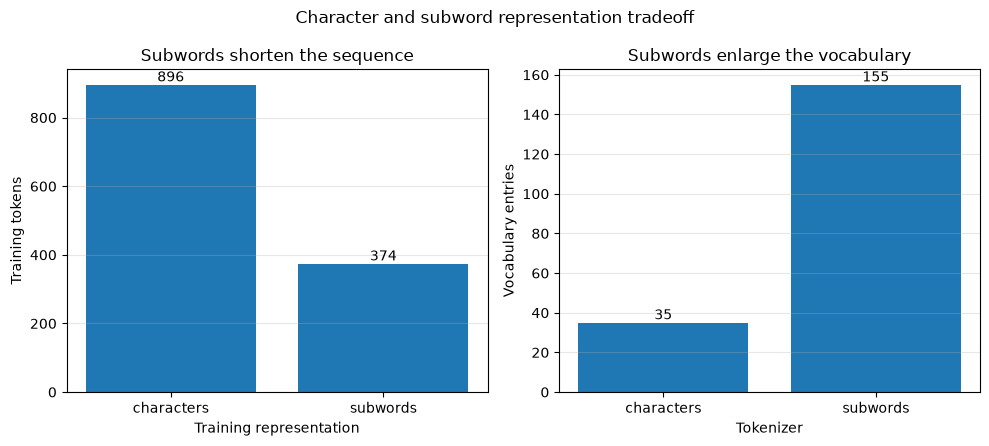

In [6]:
import matplotlib.pyplot as plt  # noqa: I001


figure, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sequence_bars = axes[0].bar(
    ["characters", "subwords"],
    [character_training_token_ids.numel(), subword_training_token_ids.numel()],
)
axes[0].bar_label(sequence_bars)
axes[0].set_xlabel("Training representation")
axes[0].set_ylabel("Training tokens")
axes[0].set_title("Subwords shorten the sequence")
axes[0].grid(axis="y", alpha=0.3)

vocabulary_bars = axes[1].bar(
    ["characters", "subwords"],
    [character_tokenizer.vocabulary_size, subword_tokenizer.vocabulary_size],
)
axes[1].bar_label(vocabulary_bars)
axes[1].set_xlabel("Tokenizer")
axes[1].set_ylabel("Vocabulary entries")
axes[1].set_title("Subwords enlarge the vocabulary")
axes[1].grid(axis="y", alpha=0.3)

figure.suptitle("Character and subword representation tradeoff")
figure.tight_layout()
plt.show()

## Build shifted GPT batches

Batching is representation-agnostic: each target row is its input row shifted one token to the left.

A dedicated random generator makes the example reproducible without coupling it to model initialization.

In [7]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    if batch_size < 1:
        raise ValueError("batch_size must be positive.")
    if context_length < 1:
        raise ValueError("context_length must be positive.")

    number_of_valid_starts = token_ids.numel() - context_length
    if number_of_valid_starts < 1:
        raise ValueError("The token stream must be longer than context_length.")

    start_indexes = torch.randint(
        low=0,
        high=number_of_valid_starts,
        size=(batch_size,),
        generator=generator,
        device=token_ids.device,
    )
    offsets = torch.arange(context_length, device=token_ids.device)
    input_indexes = start_indexes[:, None] + offsets[None, :]
    return token_ids[input_indexes], token_ids[input_indexes + 1]


batch_generator = torch.Generator(device=device).manual_seed(81)
test_input_batch, test_target_batch = get_gpt_training_batch(
    token_ids=subword_training_token_ids,
    batch_size=tiny_token_model_config["batch_size"],
    context_length=tiny_token_model_config["context_length"],
    generator=batch_generator,
)

print("Input shape:", tuple(test_input_batch.shape))
print("Target shape:", tuple(test_target_batch.shape))
print(
    "Shift is correct:",
    torch.equal(test_target_batch[:, :-1], test_input_batch[:, 1:]),
)
print("First input row:", subword_tokenizer.decode(test_input_batch[0].tolist()))

assert test_input_batch.shape == (8, 64)
assert test_target_batch.shape == (8, 64)
assert torch.equal(test_target_batch[:, :-1], test_input_batch[:, 1:])

Input shape: (8, 64)
Target shape: (8, 64)
Shift is correct: True
First input row: inning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, 


## Define TinyGPT

The architecture is unchanged from the character model: causal multi-head attention, a feedforward network, residual connections, and layer normalization.

Only the token IDs and `vocabulary_size` contract change.

In [8]:
import math


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError(
                "embedding_dimension must divide evenly by number_of_attention_heads."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        queries = (
            self.query_projection(input_values)
            .view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            )
            .transpose(1, 2)
        )
        keys = (
            self.key_projection(input_values)
            .view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            )
            .transpose(1, 2)
        )
        values = (
            self.value_projection(input_values)
            .view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            )
            .transpose(1, 2)
        )

        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        attended_values = attention_weights @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                sequence_length,
                self.embedding_dimension,
            )
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values


class PositionWiseFeedForward(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = PositionWiseFeedForward(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        values_after_attention = input_values + self.attention(
            self.attention_norm(input_values)
        )
        output_values: torch.Tensor = values_after_attention + self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding_table = torch.nn.Embedding(
            vocabulary_size, embedding_dimension
        )
        self.position_embedding_table = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("input_token_ids must have shape [batch, time].")

        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input sequence exceeds the model context length.")

        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding_table(input_token_ids)
        hidden_values = hidden_values + self.position_embedding_table(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)

        for transformer_block in self.transformer_blocks:
            hidden_values = transformer_block(hidden_values)

        logits = self.output_layer(self.final_layer_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if input_token_ids.ndim != 2 or input_token_ids.shape[1] == 0:
            raise ValueError("Generation input must have shape [batch, positive time].")
        if number_of_new_tokens < 0:
            raise ValueError("number_of_new_tokens must be nonnegative.")
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        if top_k is not None and top_k < 1:
            raise ValueError("top_k must be positive when provided.")

        generated_token_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input_ids = generated_token_ids[:, -self.context_length :]
            logits, _ = self(model_input_ids)
            next_token_logits = logits[:, -1, :] / temperature

            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_token_logits, effective_top_k)
                cutoff = top_values[:, -1, None]
                next_token_logits = next_token_logits.masked_fill(
                    next_token_logits < cutoff,
                    float("-inf"),
                )

            probabilities = torch.softmax(next_token_logits, dim=-1)
            next_token_ids = torch.multinomial(
                probabilities,
                num_samples=1,
                generator=generator,
            )
            generated_token_ids = torch.cat(
                [generated_token_ids, next_token_ids],
                dim=1,
            )

        return generated_token_ids

## Match each model to its tokenizer

The two models share every architectural hyperparameter except vocabulary size.

The subword model therefore has extra embedding and output-layer parameters.

In [9]:
def count_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


def create_model(vocabulary_size: int, seed: int) -> TinyGPT:
    torch.manual_seed(seed)
    return TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=tiny_token_model_config["context_length"],
        embedding_dimension=tiny_token_model_config["embedding_dimension"],
        number_of_attention_heads=tiny_token_model_config["number_of_attention_heads"],
        number_of_transformer_blocks=tiny_token_model_config[
            "number_of_transformer_blocks"
        ],
        dropout_rate=tiny_token_model_config["dropout_rate"],
    ).to(device)


character_model = create_model(character_tokenizer.vocabulary_size, seed=8100)
token_model = create_model(subword_tokenizer.vocabulary_size, seed=8100)

print("model         | vocabulary | parameters | output weight shape")
print("-" * 72)
print(
    f"character     | {character_model.vocabulary_size:>10} | "
    f"{count_parameters(character_model):>10} | "
    f"{tuple(character_model.output_layer.weight.shape)}"
)
print(
    f"subword       | {token_model.vocabulary_size:>10} | "
    f"{count_parameters(token_model):>10} | "
    f"{tuple(token_model.output_layer.weight.shape)}"
)

assert character_model.vocabulary_size == character_tokenizer.vocabulary_size
assert token_model.vocabulary_size == subword_tokenizer.vocabulary_size
assert count_parameters(token_model) > count_parameters(character_model)

model         | vocabulary | parameters | output weight shape
------------------------------------------------------------------------
character     |         35 |     108323 | (35, 64)
subword       |        155 |     123803 | (155, 64)


With the same batch size and context length, the subword model emits more logits because its vocabulary dimension is wider.

That structural cost can make a token-level step slower, but actual CPU speed also depends on attention, kernels, and hardware, so this notebook does not claim a universal timing result.

In [10]:
batch_size = tiny_token_model_config["batch_size"]
context_length = tiny_token_model_config["context_length"]
character_scores_per_batch = (
    batch_size * context_length * character_tokenizer.vocabulary_size
)
subword_scores_per_batch = (
    batch_size * context_length * subword_tokenizer.vocabulary_size
)

print("Character logits per batch:", character_scores_per_batch)
print("Subword logits per batch:", subword_scores_per_batch)
score_ratio = subword_scores_per_batch / character_scores_per_batch
print("Subword-to-character ratio:", round(score_ratio, 2))

test_logits, test_loss = token_model(test_input_batch, test_target_batch)
print("Token-model logits shape:", tuple(test_logits.shape))
displayed_test_loss = (
    round(float(test_loss.item()), 4) if test_loss is not None else None
)
print("Initial token-model loss:", displayed_test_loss)

assert test_logits.shape == (
    batch_size,
    context_length,
    subword_tokenizer.vocabulary_size,
)
assert test_loss is not None and torch.isfinite(test_loss)

Character logits per batch: 17920
Subword logits per batch: 79360
Subword-to-character ratio: 4.43
Token-model logits shape: (8, 64, 155)
Initial token-model loss: 5.2195


## Use one training protocol

Both models receive exactly 1,000 optimizer updates and are evaluated every 100 updates.

Evaluation samples are fixed across checkpoints, while training batches continue from their own random stream.

This controls the loop mechanics, not total source-text exposure: a 64-subword window usually covers more characters than a 64-character window.

In [11]:
from typing import Protocol


class TextTokenizer(Protocol):
    @property
    def vocabulary_size(self) -> int: ...

    def encode(self, text: str) -> list[int]: ...

    def decode(self, token_ids: list[int]) -> str: ...


@dataclass
class TrainingResult:
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    samples: dict[int, str]
    optimizer_updates: int


@torch.no_grad()
def estimate_loss(
    model: TinyGPT,
    training_token_ids: torch.Tensor,
    validation_token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    evaluation_batches: int,
    seed: int,
) -> dict[str, float]:
    if evaluation_batches < 1:
        raise ValueError("evaluation_batches must be positive.")

    was_training = model.training
    model.eval()
    mean_losses: dict[str, float] = {}

    for split_offset, (split_name, split_token_ids) in enumerate(
        [
            ("train", training_token_ids),
            ("validation", validation_token_ids),
        ]
    ):
        evaluation_generator = torch.Generator(device=device).manual_seed(
            seed + split_offset
        )
        split_losses: list[float] = []
        for _ in range(evaluation_batches):
            input_batch, target_batch = get_gpt_training_batch(
                token_ids=split_token_ids,
                batch_size=batch_size,
                context_length=context_length,
                generator=evaluation_generator,
            )
            _, loss = model(input_batch, target_batch)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation produced a non-finite loss.")
            split_losses.append(float(loss.item()))
        mean_losses[split_name] = sum(split_losses) / len(split_losses)

    model.train(was_training)
    return mean_losses


@torch.no_grad()
def generate_text_from_model(
    model: TinyGPT,
    tokenizer: TextTokenizer,
    prompt: str,
    number_of_new_tokens: int,
    seed: int,
    temperature: float = 1.0,
    top_k: int | None = 10,
) -> str:
    prompt_token_ids = tokenizer.encode(prompt)
    if not prompt_token_ids:
        raise ValueError("The prompt must encode to at least one token.")

    was_training = model.training
    model.eval()
    generation_generator = torch.Generator(device=device).manual_seed(seed)
    generated_token_ids = model.generate(
        input_token_ids=torch.tensor(
            [prompt_token_ids],
            dtype=torch.long,
            device=device,
        ),
        number_of_new_tokens=number_of_new_tokens,
        generator=generation_generator,
        temperature=temperature,
        top_k=top_k,
    )
    model.train(was_training)

    generated_id_list = generated_token_ids[0].tolist()
    generated_ids_are_valid = (
        min(generated_id_list) >= 0
        and max(generated_id_list) < tokenizer.vocabulary_size
    )
    if not generated_ids_are_valid:
        raise RuntimeError(
            "The model generated an ID outside the tokenizer vocabulary."
        )
    return tokenizer.decode(generated_id_list)

The loop evaluates the untrained model at step 0, performs exactly 1,000 updates, and evaluates the final model at step 1,000.

Samples are limited to steps 0, 500, and 1,000 so the output remains useful rather than repetitive.

In [12]:
def train_tiny_gpt(
    model: TinyGPT,
    tokenizer: TextTokenizer,
    training_token_ids: torch.Tensor,
    validation_token_ids: torch.Tensor,
    config: TinyModelConfig,
    prompt: str,
    sample_token_count: int,
    training_seed: int,
    evaluation_seed: int,
    sampling_seed: int,
    evaluation_batches: int = 5,
) -> TrainingResult:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
    )
    training_generator = torch.Generator(device=device).manual_seed(training_seed)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []
    samples: dict[int, str] = {}
    sample_steps = {0, config["training_steps"] // 2, config["training_steps"]}

    def record_checkpoint(step: int) -> None:
        losses = estimate_loss(
            model=model,
            training_token_ids=training_token_ids,
            validation_token_ids=validation_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            evaluation_batches=evaluation_batches,
            seed=evaluation_seed,
        )
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        print(
            f"step {step:>4} | train loss {losses['train']:.4f} | "
            f"validation loss {losses['validation']:.4f}"
        )
        if step in sample_steps:
            samples[step] = generate_text_from_model(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                number_of_new_tokens=sample_token_count,
                seed=sampling_seed + step,
            )
            print(f"sample at step {step}:")
            print(samples[step])
            print("-" * 72)

    model.train()
    record_checkpoint(step=0)

    optimizer_updates = 0
    for step in range(1, config["training_steps"] + 1):
        input_batch, target_batch = get_gpt_training_batch(
            token_ids=training_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            generator=training_generator,
        )
        logits, loss = model(input_batch, target_batch)
        if logits.shape[-1] != model.vocabulary_size:
            raise RuntimeError("Logit vocabulary dimension does not match the model.")
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training produced a non-finite loss.")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        optimizer_updates += 1

        if step % config["evaluation_interval"] == 0:
            record_checkpoint(step=step)

    if optimizer_updates != config["training_steps"]:
        raise RuntimeError("The optimizer update count does not match training_steps.")

    return TrainingResult(
        evaluation_steps=evaluation_steps,
        training_losses=training_losses,
        validation_losses=validation_losses,
        samples=samples,
        optimizer_updates=optimizer_updates,
    )

## Train the token-level model

The main run predicts homemade subword IDs and decodes sampled IDs with the same tokenizer.

In [13]:
token_training_result = train_tiny_gpt(
    model=token_model,
    tokenizer=subword_tokenizer,
    training_token_ids=subword_training_token_ids,
    validation_token_ids=subword_validation_token_ids,
    config=tiny_token_model_config,
    prompt="Alice",
    sample_token_count=40,
    training_seed=8101,
    evaluation_seed=8111,
    sampling_seed=8121,
)

assert token_training_result.optimizer_updates == 1000
assert (
    token_training_result.training_losses[-1] < token_training_result.training_losses[0]
)

step    0 | train loss 5.2242 | validation loss 5.2046
sample at step 0:
Aliceetrabbit uoft by herich ons ,  a vereeT

Iorict ed tusis
aning conwas aritAlice  a ccisterl tnothttu
------------------------------------------------------------------------


step  100 | train loss 4.2382 | validation loss 4.5189


step  200 | train loss 3.2315 | validation loss 4.4961


step  300 | train loss 2.3751 | validation loss 4.5769


step  400 | train loss 1.7459 | validation loss 4.7679


...

step  600 | train loss 0.9430 | validation loss 5.3146


step  700 | train loss 0.6829 | validation loss 5.6447


step  800 | train loss 0.5079 | validation loss 5.8675


step  900 | train loss 0.3783 | validation loss 6.1281


step 1000 | train loss 0.2994 | validation loss 6.3646
sample at step 1000:
Alice, with pink es ran clot is
chat dayell as she was could be  very sle in thathere 
------------------------------------------------------------------------


The training loss falls sharply, so the model learns next-subword patterns in this tiny corpus.

The held-out loss bottoms out early and then rises, which is evidence of overfitting rather than continued generalization.

Generated text can still repeat or copy the training passage because both the dataset and model are small.

## Train the character-level comparison

The baseline uses the same architecture and number of updates, but its 64-token context contains exactly 64 characters.

In [14]:
character_training_result = train_tiny_gpt(
    model=character_model,
    tokenizer=character_tokenizer,
    training_token_ids=character_training_token_ids,
    validation_token_ids=character_validation_token_ids,
    config=tiny_token_model_config,
    prompt="Alice",
    sample_token_count=100,
    training_seed=8201,
    evaluation_seed=8211,
    sampling_seed=8221,
)

assert character_training_result.optimizer_updates == 1000
assert (
    character_training_result.training_losses[-1]
    < character_training_result.training_losses[0]
)

step    0 | train loss 3.7097 | validation loss 3.6412
sample at step 0:
AlicenAScn!ac;t!aba;ydttn
mnt!pwk?a,o;h;vAetnmOTpytyeeac!pwucSBdfeampungn!sArAm;A?kmea,g?yTyt,,;ygsbTpdOu
------------------------------------------------------------------------


step  100 | train loss 2.6374 | validation loss 2.8034


step  200 | train loss 2.3433 | validation loss 2.6745


step  300 | train loss 2.2369 | validation loss 2.6435


step  400 | train loss 2.1635 | validation loss 2.6387


...

step  600 | train loss 2.0711 | validation loss 2.6695


step  700 | train loss 2.0259 | validation loss 2.6619


step  800 | train loss 1.9672 | validation loss 2.6873


step  900 | train loss 1.9155 | validation loss 2.7207


step 1000 | train loss 1.8532 | validation loss 2.7260
sample at step 1000:
Alicers on
thoked he whath ang r win bbicerok, wabyof wat sis che so sinsererelisit; oonve d, he das, bll
------------------------------------------------------------------------


## Compare loss curves carefully

Cross-entropy here is measured in natural-log units per predicted token.

Character and subword losses are not directly interchangeable because their prediction units and vocabulary sizes differ.

For context, a uniform predictor starts near `log(vocabulary_size)`, which is different for the two tokenizers.

Character uniform baseline: 3.5553
Subword uniform baseline: 5.0434


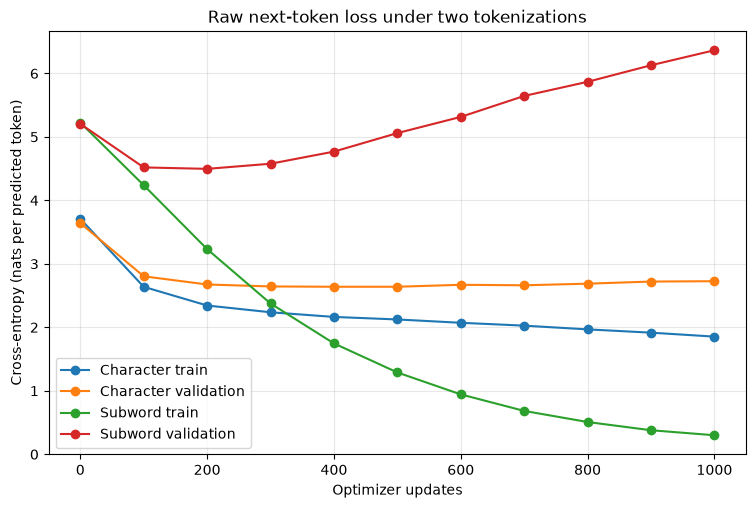

In [15]:
print(
    "Character uniform baseline:",
    round(math.log(character_tokenizer.vocabulary_size), 4),
)
print(
    "Subword uniform baseline:",
    round(math.log(subword_tokenizer.vocabulary_size), 4),
)

plt.figure(figsize=(9, 5.5))
plt.plot(
    character_training_result.evaluation_steps,
    character_training_result.training_losses,
    marker="o",
    label="Character train",
)
plt.plot(
    character_training_result.evaluation_steps,
    character_training_result.validation_losses,
    marker="o",
    label="Character validation",
)
plt.plot(
    token_training_result.evaluation_steps,
    token_training_result.training_losses,
    marker="o",
    label="Subword train",
)
plt.plot(
    token_training_result.evaluation_steps,
    token_training_result.validation_losses,
    marker="o",
    label="Subword validation",
)
plt.xlabel("Optimizer updates")
plt.ylabel("Cross-entropy (nats per predicted token)")
plt.title("Raw next-token loss under two tokenizations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The curves answer whether each model improves on its own next-token task.

They do not establish which tokenizer is universally better or which model uses compute more efficiently.

The widening train-validation gaps also show why held-out evaluation matters on a tiny dataset.

## Inspect the final samples

The subword sample uses fewer generated tokens because each token can contain several characters.

In [16]:
print("FINAL SUBWORD SAMPLE")
print("=" * 72)
print(token_training_result.samples[1000])

print()
print("FINAL CHARACTER SAMPLE")
print("=" * 72)
print(character_training_result.samples[1000])

FINAL SUBWORD SAMPLE
Alice, with pink es ran clot is
chat dayell as she was could be  very sle in thathere 

FINAL CHARACTER SAMPLE
Alicers on
thoked he whath ang r win bbicerok, wabyof wat sis che so sinsererelisit; oonve d, he das, bll


Both decoders reconstruct text from IDs produced inside their own vocabularies.

Using the other tokenizer would assign different meanings to those same integers.

## Verify the final contracts

These checks collect the most common token-level failure modes in one place.

In [17]:
assert subword_tokenizer.decode(subword_training_id_list) == training_text
assert subword_tokenizer.decode(subword_validation_id_list) == validation_text
subword_all_token_ids_max = subword_training_token_ids.max().item()
assert subword_all_token_ids_max < token_model.vocabulary_size
assert token_model.output_layer.out_features == subword_tokenizer.vocabulary_size
assert token_training_result.evaluation_steps == list(range(0, 1001, 100))
assert character_training_result.evaluation_steps == list(range(0, 1001, 100))
assert all(math.isfinite(loss) for loss in token_training_result.training_losses)
assert all(math.isfinite(loss) for loss in token_training_result.validation_losses)

print("Round trip: passed")
print("Token-ID range: passed")
print("Tokenizer/model vocabulary match: passed")
print("Exact optimizer-update count: passed")
print("Finite checkpoint losses: passed")

Round trip: passed
Token-ID range: passed
Tokenizer/model vocabulary match: passed
Exact optimizer-update count: passed
Finite checkpoint losses: passed


## Common mistakes

- Building the token model with the character vocabulary size causes invalid embedding lookups or a mismatched output layer.

- Training the tokenizer on validation text leaks held-out distribution information into the vocabulary and merge rules.

- Comparing raw character and subword loss as if they predicted the same unit gives a misleading quality conclusion.

- Evaluating at step 1,000 and then taking one more optimizer step silently trains for 1,001 updates.

- Decoding generated IDs with a different tokenizer changes their meanings.

- Expecting fewer corpus tokens to guarantee faster individual steps ignores the wider vocabulary dimension.

## Takeaways

- TinyGPT trains on integer IDs without caring whether an ID represents a character or a subword.

- The token-level model must use `subword_tokenizer.vocabulary_size`.

- Subwords shorten the corpus token sequence but enlarge the embedding table, output layer, and logit tensor.

- The requested run performs exactly 1,000 CPU optimizer updates and tracks deterministic training and validation loss.

- Raw character and subword loss curves diagnose learning within each tokenization, not an apples-to-apples model ranking.

- Generated IDs must be decoded with the tokenizer that defined their vocabulary.

## What comes next

A practical token-level system should save the model weights, tokenizer state, architecture configuration, and optimizer state together.

That shared checkpoint preserves the meaning of every token ID when training resumes or generation runs later.